# Predictive Modeling for Movie Preferences Using Machine Learning Models

# Import Statements

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


# Loading and Merging Movielens dataset

In [ ]:
import pandas as pd

# Loading the dataset for our project
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

# Merge ratings with movie titles
movielens_dataset = pd.merge(ratings, movies, on='movieId')




In [ ]:
# View first few rows in our movie lens dataset
print(movielens_dataset.head())

   userId  movieId  rating   timestamp  \
0       1        2     3.5  1112486027   
1       1       29     3.5  1112484676   
2       1       32     3.5  1112484819   
3       1       47     3.5  1112484727   
4       1       50     3.5  1112484580   

                                               title  \
0                                     Jumanji (1995)   
1  City of Lost Children, The (Cité des enfants p...   
2          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   
3                        Seven (a.k.a. Se7en) (1995)   
4                         Usual Suspects, The (1995)   

                                   genres  
0              Adventure|Children|Fantasy  
1  Adventure|Drama|Fantasy|Mystery|Sci-Fi  
2                 Mystery|Sci-Fi|Thriller  
3                        Mystery|Thriller  
4                  Crime|Mystery|Thriller  


In [ ]:
movielens_dataset = movielens_dataset.sample(100000, random_state=42)


In [ ]:

# Checking the features and no. of records in the dataset

print("The number of records are : ", movielens_dataset.shape[0])
print("The number of features are : ", movielens_dataset.shape[1])
print("The list of features is : ", movielens_dataset.columns)
movielens_dataset.head()

The number of records are :  100000
The number of features are :  6
The list of features is :  Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')


,userId,movieId,rating,timestamp,title,genres
17679788,122270,8360,3.5,1335056824,Shrek 2 (2004),Adventure|Animation|Children|Comedy|Musical|Ro...
7106385,49018,32,2.0,1000194636,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
12970708,89527,109374,3.5,1420536400,"Grand Budapest Hotel, The (2014)",Comedy|Drama
15426752,106704,1060,3.0,948576477,Swingers (1996),Comedy|Drama
6934678,47791,1732,2.0,1137685703,"Big Lebowski, The (1998)",Comedy|Crime


# Data Preprocessing

 Preprocessing + Null Check + Datetime Conversion

# Handling missing values

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for null values
print("Null values in our dataset are :\n", movielens_dataset.isnull().sum())


Null values in our dataset are :
 userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64


In [ ]:

# Convert timestamp to datetime
movielens_dataset['timestamp'] = pd.to_datetime(movielens_dataset['timestamp'], unit='s')
movielens_dataset['year'] = movielens_dataset['timestamp'].dt.year



In [ ]:

# Show sample after conversion
print("Sample after conversion :\n", movielens_dataset.head())
print(movielens_dataset[['userId', 'movieId', 'rating', 'timestamp', 'year']].head())

Sample after conversion :
           userId  movieId  rating           timestamp  \
17679788  122270     8360     3.5 2012-04-22 01:07:04   
7106385    49018       32     2.0 2001-09-11 07:50:36   
12970708   89527   109374     3.5 2015-01-06 09:26:40   
15426752  106704     1060     3.0 2000-01-22 21:27:57   
6934678    47791     1732     2.0 2006-01-19 15:48:23   

                                              title  \
17679788                             Shrek 2 (2004)   
7106385   Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   
12970708           Grand Budapest Hotel, The (2014)   
15426752                            Swingers (1996)   
6934678                    Big Lebowski, The (1998)   

                                                     genres  year  
17679788  Adventure|Animation|Children|Comedy|Musical|Ro...  2012  
7106385                             Mystery|Sci-Fi|Thriller  2001  
12970708                                       Comedy|Drama  2015  
15426752                   

In [ ]:

# Checking the columns' titles and datatypes
print("The columns' titles and datatypes are :\n", movielens_dataset.dtypes)
movielens_dataset.info()

The columns' titles and datatypes are :
 userId                int64
movieId               int64
rating              float64
timestamp    datetime64[ns]
title                object
genres               object
year                  int32
dtype: object
<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 17679788 to 12437091
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   userId     100000 non-null  int64         
 1   movieId    100000 non-null  int64         
 2   rating     100000 non-null  float64       
 3   timestamp  100000 non-null  datetime64[ns]
 4   title      100000 non-null  object        
 5   genres     100000 non-null  object        
 6   year       100000 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(2)
memory usage: 5.7+ MB


4. Ratings Range Check

In [ ]:
print("Below are the movie ratings by the uyser in our dataset")
print(f"Rating range: {movielens_dataset['rating'].min()} to {movielens_dataset['rating'].max()}")



Below are the movie ratings by the uyser in our dataset
Rating range: 0.5 to 5.0


In [ ]:
# 5. Basic Dataset Info
print("Dataset Info like unique users, movies and number of  records:")

print(f"Unique Users: {movielens_dataset['userId'].nunique()}")
print(f"Unique Movies: {movielens_dataset['movieId'].nunique()}")
print(f"Total Records: {len(movielens_dataset)}")

Dataset Info like unique users, movies and number of  records:
Unique Users: 52112
Unique Movies: 8466
Total Records: 100000


# Exploratory Data Analysis (EDA)

# 1. Ratings Distribution

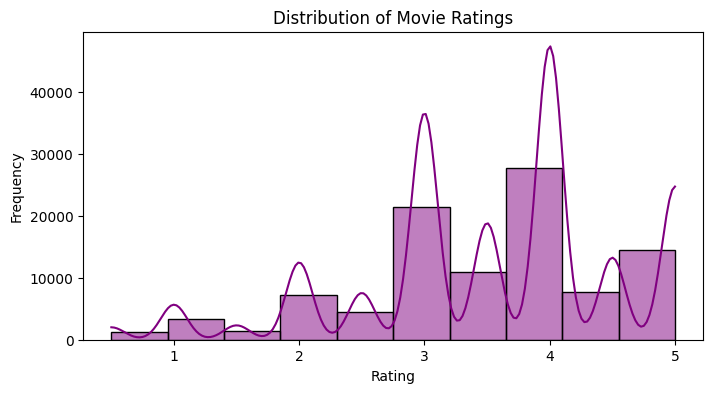

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(movielens_dataset['rating'], bins=10, kde=True, color ='purple')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


# 2. Most Rated Movies

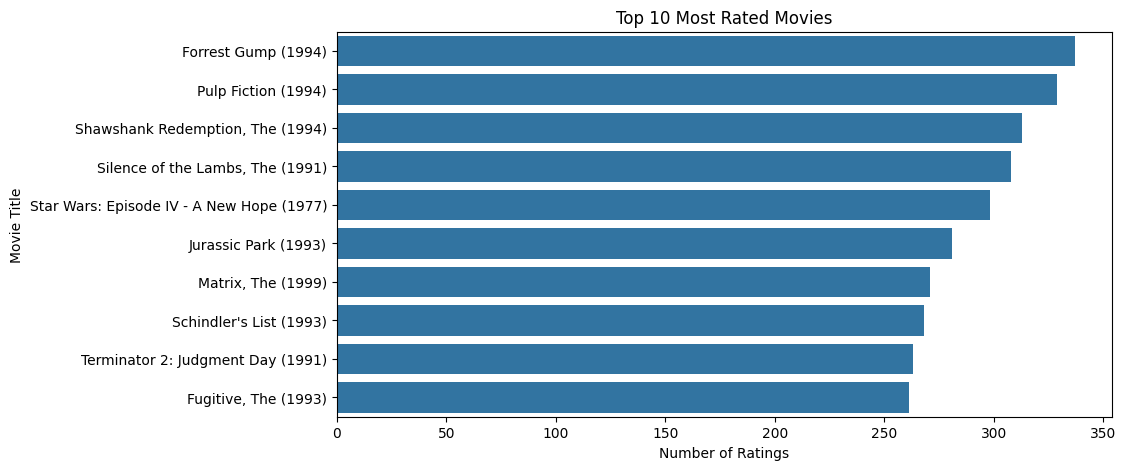

In [ ]:


top_movies = movielens_dataset['title'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_movies.values, y=top_movies.index)
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()


# 3. Active Users (users who rate a lot)

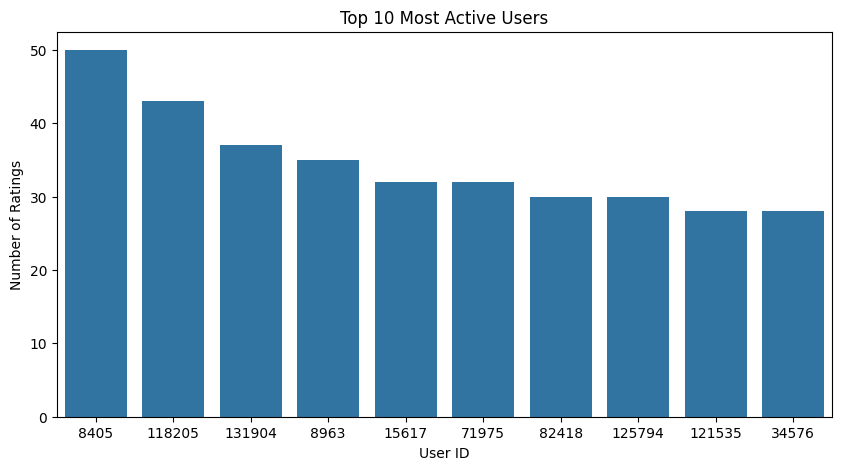

In [ ]:
top_users = movielens_dataset['userId'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_users.index.astype(str), y=top_users.values)
plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.show()


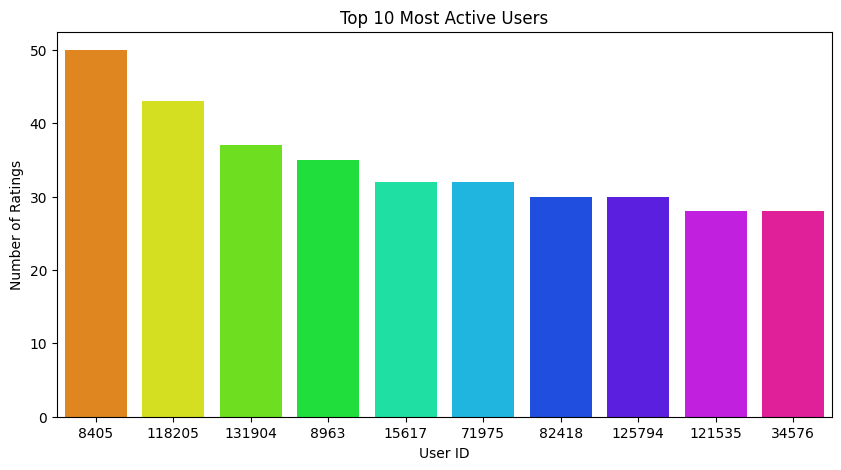

In [ ]:

top_users = movielens_dataset['userId'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_users.index.astype(str),
    y=top_users.values,
    palette=sns.color_palette("hsv", len(top_users))  # or try "Set2", "coolwarm", etc.
)
plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.show()

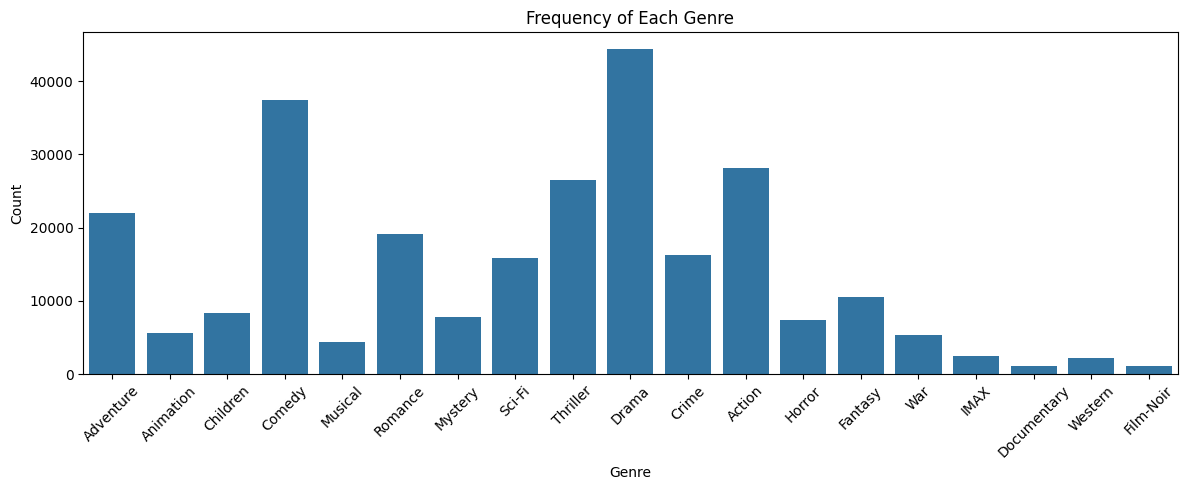

In [ ]:
from collections import Counter

# Flatten all genres
genre_series = movielens_dataset['genres'].str.split('|')
all_genres = [genre for sublist in genre_series for genre in sublist]
genre_counts = Counter(all_genres)

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(x=list(genre_counts.keys()), y=list(genre_counts.values()))
plt.title('Frequency of Each Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Below graph is the Frequency of each genre in our dataset


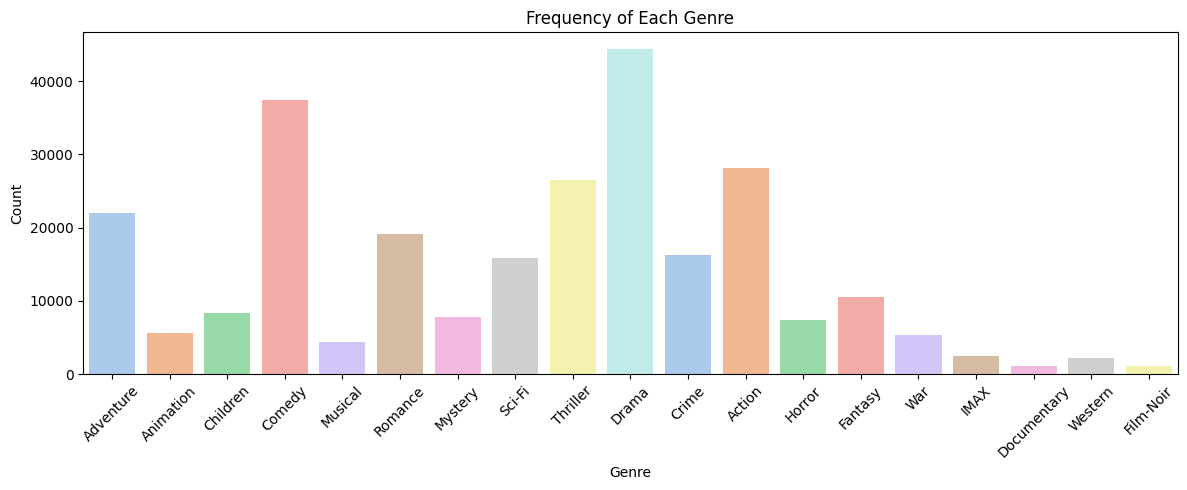

In [ ]:
print("Below graph is the Frequency of each genre in our dataset")
genre_series = movielens_dataset['genres'].str.split('|')
all_genres = [genre for sublist in genre_series for genre in sublist]
genre_counts = Counter(all_genres)

# Prepare data for plotting
genres = list(genre_counts.keys())
counts = list(genre_counts.values())

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(x=genres, y=counts, palette='pastel')  # You can also try 'muted', 'deep', etc.
plt.title('Frequency of Each Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribution of Ratings per Movie

Plotting distribution of number of ratings per movie


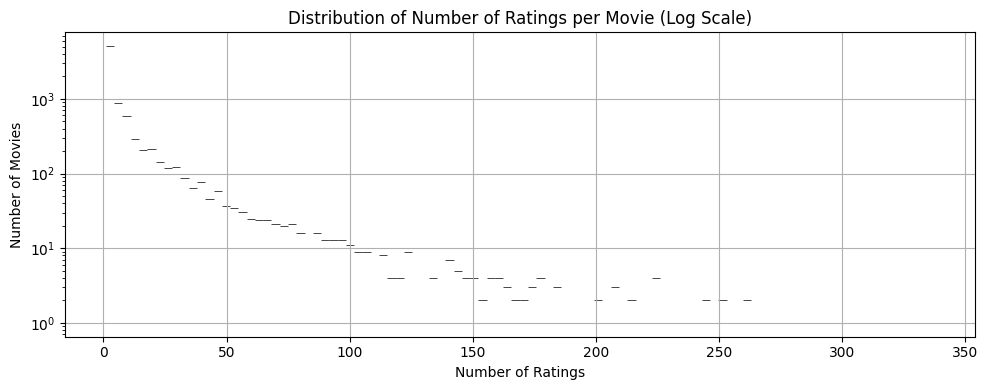

In [ ]:
print("Plotting distribution of number of ratings per movie")

import matplotlib.pyplot as plt
import seaborn as sns

movie_rating_counts = movielens_dataset.groupby('title')['rating'].count()

plt.figure(figsize=(10, 4))
sns.histplot(movie_rating_counts, bins=100, log_scale=(False, True))
plt.title('Distribution of Number of Ratings per Movie (Log Scale)')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.tight_layout()
plt.show()


# 2. Top 15 Highest Rated Movies (min 500 ratings)

Checking how many movies have at least 500 ratings...
Number of movies with ≥ 500 ratings: 0
Less than 15 movies with 500+ ratings. Lowering threshold to 100.
Plotting bar chart now...


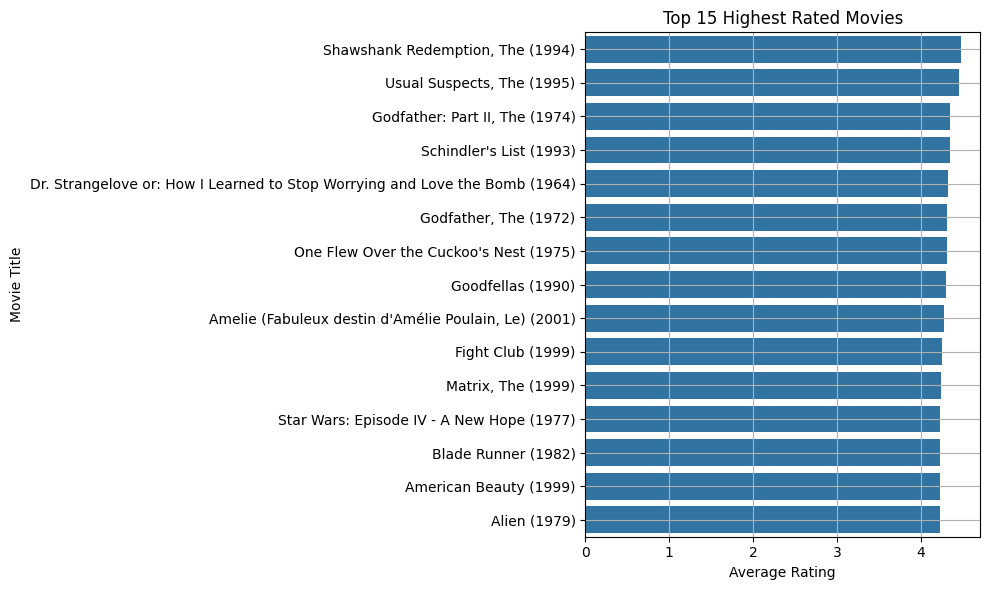

In [ ]:
print("Checking how many movies have at least 500 ratings...")
top_rated = movielens_dataset.groupby('title').agg({'rating': ['mean', 'count']})
top_rated.columns = ['avg_rating', 'rating_count']

# Print how many movies meet the 500+ condition
num_movies_500 = (top_rated['rating_count'] >= 500).sum()
print(f"Number of movies with ≥ 500 ratings: {num_movies_500}")

# Lower threshold if needed
if num_movies_500 < 15:
    print("Less than 15 movies with 500+ ratings. Lowering threshold to 100.")
    top_rated_filtered = top_rated[top_rated['rating_count'] >= 100]
else:
    top_rated_filtered = top_rated[top_rated['rating_count'] >= 500]

# Sort and plot
top_15 = top_rated_filtered.sort_values('avg_rating', ascending=False).head(15)

print("Plotting bar chart now...")
plt.figure(figsize=(10, 6))
sns.barplot(x=top_15['avg_rating'], y=top_15.index)
plt.title('Top 15 Highest Rated Movies')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')
plt.grid(True)
plt.tight_layout()
plt.show()


# Ratings Over Years (Average Rating Trend)

Plotting average movie rating by year


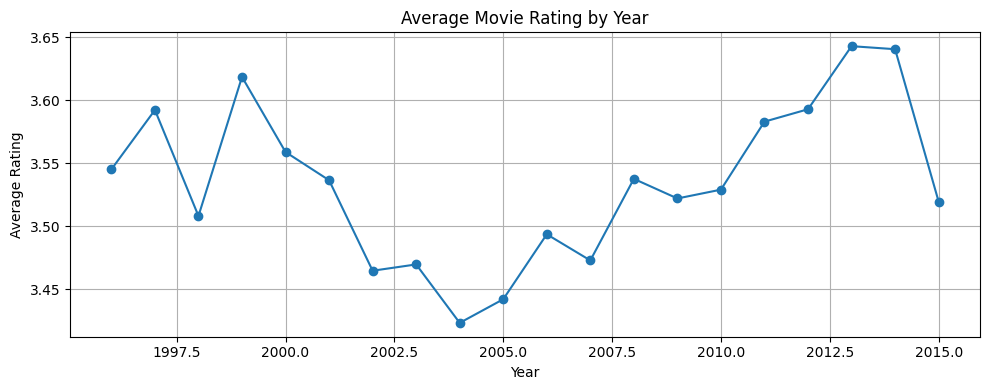

In [ ]:
print("Plotting average movie rating by year")

avg_rating_by_year = movielens_dataset.groupby('year')['rating'].mean()

plt.figure(figsize=(10, 4))
avg_rating_by_year.plot(marker='o')
plt.title('Average Movie Rating by Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()


# Feature Engineering

# 1. Multi-Hot Encoding for Genres


In [ ]:
# Multi-hot encoding for genres
print("🔹 Step 1: Multi-hot encoding for genres in our MovieLens dataset")

genre_split_df = movielens_dataset['genres'].str.get_dummies(sep='|')
movielens_dataset = pd.concat([movielens_dataset, genre_split_df], axis=1)

print("Genre columns added. Sample:\n")
print(movielens_dataset[['title', 'genres'] + list(genre_split_df.columns)].head())


🔹 Step 1: Multi-hot encoding for genres in our MovieLens dataset
Genre columns added. Sample:

                                              title  \
17679788                             Shrek 2 (2004)   
7106385   Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   
12970708           Grand Budapest Hotel, The (2014)   
15426752                            Swingers (1996)   
6934678                    Big Lebowski, The (1998)   

                                                     genres  Action  \
17679788  Adventure|Animation|Children|Comedy|Musical|Ro...       0   
7106385                             Mystery|Sci-Fi|Thriller       0   
12970708                                       Comedy|Drama       0   
15426752                                       Comedy|Drama       0   
6934678                                        Comedy|Crime       0   

          Adventure  Animation  Children  Comedy  Crime  Documentary  Drama  \
17679788          1          1         1       1      0            0

# 2. Add Average Rating per Movie

In [ ]:
# Average rating and rating count per movie
print("\nComputing average rating and total rating count for each movie")

movie_stats = movielens_dataset.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
movie_stats.rename(columns={'mean': 'avg_rating', 'count': 'rating_count'}, inplace=True)

movielens_dataset = pd.merge(movielens_dataset, movie_stats, on='movieId', how='left')

print("Rating stats added. Sample:\n")
print(movielens_dataset[['title', 'avg_rating', 'rating_count']].head())



Computing average rating and total rating count for each movie
Rating stats added. Sample:

                                       title  avg_rating  rating_count
0                             Shrek 2 (2004)    3.626667            75
1  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)    3.903084           227
2           Grand Budapest Hotel, The (2014)    4.076923            13
3                            Swingers (1996)    3.950000            40
4                   Big Lebowski, The (1998)    3.912621           103


# Normalize rating count for modeling

In [ ]:
# Normalize rating count (optional for ML models)
print("\n🔹 Step 3: Normalizing rating count between 0 and 1 (optional)")

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
movielens_dataset['rating_count_scaled'] = scaler.fit_transform(movielens_dataset[['rating_count']])

print("✅ Scaled popularity metric added. Sample:\n")
print(movielens_dataset[['title', 'rating_count', 'rating_count_scaled']].head())



🔹 Step 3: Normalizing rating count between 0 and 1 (optional)
✅ Scaled popularity metric added. Sample:

                                       title  rating_count  \
0                             Shrek 2 (2004)            75   
1  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)           227   
2           Grand Budapest Hotel, The (2014)            13   
3                            Swingers (1996)            40   
4                   Big Lebowski, The (1998)           103   

   rating_count_scaled  
0             0.220238  
1             0.672619  
2             0.035714  
3             0.116071  
4             0.303571  


# Model Implementation for our movielens dataset

# PHASE 1: TF-IDF + Logistic Regression (Content-Based)

In [ ]:
print("Step 1: Using TF-IDF on genres and Logistic Regression for similarity")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

# Create a new column with genre string (just in case it's not clean)
movielens_dataset['genres_clean'] = movielens_dataset['genres'].fillna('')



Step 1: Using TF-IDF on genres and Logistic Regression for similarity


# TF-IDF Vectorization on genres

In [ ]:

# TF-IDF Vectorization on genres
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movielens_dataset['genres_clean'])

print("✅ TF-IDF Matrix Shape:", tfidf_matrix.shape)



✅ TF-IDF Matrix Shape: (100000, 21)


# Logistic Regression for Classification

In [ ]:
print("Training Logistic Regression to predict if user likes a movie (rating ≥ 4)")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score, accuracy_score

# Step 1: Create target column
movielens_dataset['liked'] = (movielens_dataset['rating'] >= 4).astype(int)

# Step 2: Select features (multi-hot genres + avg rating + rating count)
features = genre_split_df.copy()
features['avg_rating'] = movielens_dataset['avg_rating']
features['rating_count_scaled'] = movielens_dataset['rating_count_scaled']
X = features
y = movielens_dataset['liked']


Training Logistic Regression to predict if user likes a movie (rating ≥ 4)


# Training and splitting the dataset for logistic regression

In [ ]:
# Step 3: Handle missing values
features.fillna(0, inplace=True)

X = features
y = movielens_dataset['liked']
# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train logistic regression
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Step 5: Evaluation
print("Classification Report for logistic regression model:\n")
print(classification_report(y_test, y_pred))


Classification Report for logistic regression model:

              precision    recall  f1-score   support

           0       0.58      0.56      0.57     10047
           1       0.57      0.60      0.58      9953

    accuracy                           0.58     20000
   macro avg       0.58      0.58      0.58     20000
weighted avg       0.58      0.58      0.58     20000



# Evaluation metrics for logistic rgeression

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nLogistic Regression Evaluation on MovieLens Dataset:")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")



Logistic Regression Evaluation on MovieLens Dataset:
Accuracy       : 0.5461
Precision      : 0.6029
Recall         : 0.2573
F1 Score       : 0.3607


# KNN model TFIDF VECTORIZATION

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization on genres
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movielens_dataset['genres_clean'])

print("✅ TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("🔄 Using NearestNeighbors with cosine distance instead of full similarity matrix")

from sklearn.neighbors import NearestNeighbors

# Fit Nearest Neighbors on TF-IDF matrix
nn_model = NearestNeighbors(metric='cosine', algorithm='brute')
nn_model.fit(tfidf_matrix)


✅ TF-IDF Matrix Shape: (100000, 21)
🔄 Using NearestNeighbors with cosine distance instead of full similarity matrix


NearestNeighbors(algorithm='brute', metric='cosine')

In [ ]:

# Map titles to indices
indices = pd.Series(movielens_dataset.index, index=movielens_dataset['title']).drop_duplicates()

# New recommendation function
def recommend_movies_nn(title, n_recommendations=10):
    idx = indices[title]
    distances, indices_nn = nn_model.kneighbors(tfidf_matrix[idx], n_neighbors=n_recommendations + 1)
    recommendations = movielens_dataset['title'].iloc[indices_nn[0][1:]]
    return recommendations

# Try it
print("📢 Top 10 genre-based recommendations for 'Toy Story (1995)':")
print(recommend_movies_nn('Toy Story (1995)'))


📢 Top 10 genre-based recommendations for 'Toy Story (1995)':
1662                     Toy Story (1995)
35313                  Toy Story 2 (1999)
84633                    Toy Story (1995)
59707    Emperor's New Groove, The (2000)
59687                  Toy Story 2 (1999)
35429                  Toy Story 2 (1999)
84527                    Toy Story (1995)
59596                    Toy Story (1995)
59824               Monsters, Inc. (2001)
35979                         Antz (1998)
Name: title, dtype: object


# K-Nearest Neighbors (KNN) Collaborative Filtering

In [ ]:
!pip install scikit-surprise


# Load Data into surprise Format

In [ ]:
print(" Loading MovieLens ratings into surprise Dataset format")

from surprise import Dataset, Reader
from surprise.model_selection import train_test_split

# Prepare reader and load DataFrame
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(movielens_dataset[['userId', 'movieId', 'rating']], reader)

# Split into train and test set
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)


 Loading MovieLens ratings into surprise Dataset format


# 3: Train KNN Collaborative Filtering Model

In [ ]:
!pip install numpy==1.26.4


In [ ]:
print("Sampling 100,000 rows for collaborative filtering to avoid memory crash")

from surprise import Dataset, Reader, KNNBasic, accuracy
from surprise.model_selection import train_test_split

# Step 1: Sample the dataset
movielens_sample = movielens_dataset.sample(100_000, random_state=42)

# Step 2: Load into surprise format
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(movielens_sample[['userId', 'movieId', 'rating']], reader)

# Step 3: Train/test split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Step 4: Train KNN (item-based for better efficiency)
print("🤖 Training item-based KNN Collaborative Filtering model...")
sim_options = {
    'name': 'cosine',
    'user_based': False  # Item-based CF
}

knn_model = KNNBasic(sim_options=sim_options)
knn_model.fit(trainset)

# Step 5: Predictions
predictions = knn_model.test(testset)

# Step 6: Evaluation
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

print(f"\n✅ RMSE : {rmse:.4f}")
print(f"✅ MAE  : {mae:.4f}")


Sampling 100,000 rows for collaborative filtering to avoid memory crash
🤖 Training item-based KNN Collaborative Filtering model...
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0705
MAE:  0.8507

✅ RMSE : 1.0705
✅ MAE  : 0.8507


# 4: Recommend Movies for a Given User

In [ ]:
def get_top_n_recommendations(predictions, user_id, n=10):
    # Filter predictions for the specific user
    user_predictions = [pred for pred in predictions if pred.uid == user_id]
    user_predictions.sort(key=lambda x: x.est, reverse=True)

    top_n = user_predictions[:n]
    movie_ids = [int(pred.iid) for pred in top_n]

    return movielens_dataset[movielens_dataset['movieId'].isin(movie_ids)][['title', 'avg_rating']].drop_duplicates()

# Get a list of available user IDs in the sample
unique_users = movielens_sample['userId'].unique()
print(f"✅ Total Users in Sample: {len(unique_users)}")
print("🎯 Sample user IDs:", unique_users[:10])



✅ Total Users in Sample: 52112
🎯 Sample user IDs: [ 56927  90093  17040  97049 105452  41089  39381 100780  61612  50855]


In [ ]:
print("\n🎬 Top 10 movie recommendations for user 17040 :")
print(get_top_n_recommendations(predictions, user_id=17040 ))



🎬 Top 10 movie recommendations for user 17040 :
                                            title  avg_rating
6010                      Shanghai Knights (2003)    3.038462
19864                        Robot Stories (2003)    3.500000
92856  Fubar II (Fubar: Balls to the Wall) (2010)    3.500000


In [ ]:
print("\n🎬 Top 10 movie recommendations for user 39381 :")
print(get_top_n_recommendations(predictions, user_id= 39381 ))



🎬 Top 10 movie recommendations for user 39381 :
                    title  avg_rating
15435  Hard Target (1993)    2.636364


# Knn model for classification for our movielen dataset


In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Training KNN Classifier to predict if a user will like a movie")

# Step 1: Create binary target
movielens_dataset['liked'] = (movielens_dataset['rating'] >= 4).astype(int)

# Step 2: Use genre features + stats
features = genre_split_df.copy()
features['avg_rating'] = movielens_dataset['avg_rating']
features['rating_count_scaled'] = movielens_dataset['rating_count_scaled']
features.fillna(0, inplace=True)

X = features
y = movielens_dataset['liked']

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: KNN Classifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)


Training KNN Classifier to predict if a user will like a movie


# Evaluating the KNN model fwith our dataset

In [ ]:
# Step 5: Metrics
accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
recall = recall_score(y_test, y_pred_knn)
f1 = f1_score(y_test, y_pred_knn)

print(f"""
KNN Classifier Evaluation on MovieLens Dataset:
-------------------------------------------------------
Accuracy       : {accuracy:.4f}
Precision      : {precision:.4f}
Recall         : {recall:.4f}
F1 Score       : {f1:.4f}
""")



KNN Classifier Evaluation on MovieLens Dataset:
-------------------------------------------------------
Accuracy       : 0.5700
Precision      : 0.5728
Recall         : 0.5353
F1 Score       : 0.5534



# 3: XGBoost — Rating Prediction (Regression)



In [ ]:
print("Training XGBoost Regressor to predict movie ratings")

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Features
X = genre_split_df.copy()
X['avg_rating'] = movielens_dataset['avg_rating']
X['rating_count_scaled'] = movielens_dataset['rating_count_scaled']
X.fillna(0, inplace=True)

# Target
y = movielens_dataset['rating']



Training XGBoost Regressor to predict movie ratings


# Training and testing split in XGboost

In [ ]:
 # Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)


# Evaluation of XGboost model

In [ ]:

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"""
XGBoost Regressor Evaluation:
-------------------------------
RMSE : {rmse:.4f}
MAE  : {mae:.4f}
""")



XGBoost Regressor Evaluation:
-------------------------------
RMSE : 0.6738
MAE  : 0.4540



# 4: Naive Bayes — Classification (Liked/Not Liked)

In [ ]:
print("Training Naive Bayes Classifier for liked/not liked prediction")

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Target
movielens_dataset['liked'] = (movielens_dataset['rating'] >= 4).astype(int)

# Reuse previous feature set
X = genre_split_df.copy()
X['avg_rating'] = movielens_dataset['avg_rating']
X['rating_count_scaled'] = movielens_dataset['rating_count_scaled']
X.fillna(0, inplace=True)
y = movielens_dataset['liked']



Training Naive Bayes Classifier for liked/not liked prediction


# Training and testing split in of Naive Bayes

In [ ]:

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)


# Evaluation of Naive Bayes

In [ ]:

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"""
 Naive Bayes Evaluation on MovieLens Dataset:
-----------------------------------------------
 Accuracy       : {accuracy:.4f}
 Precision      : {precision:.4f}
 Recall         : {recall:.4f}
 F1 Score       : {f1:.4f}
""")


 Naive Bayes Evaluation on MovieLens Dataset:
-----------------------------------------------
 Accuracy       : 0.5461
 Precision      : 0.6029
 Recall         : 0.2573
 F1 Score       : 0.3607



Evaluation metrics comparison of different models

# Create DataFrames with Real Results

In [ ]:
import pandas as pd

classification_metrics = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN Classifier', 'Naive Bayes'],
    'Accuracy':    [0.5780, 0.5700, 0.5461],
    'Precision':   [0.5732, 0.5728, 0.6029],
    'Recall':      [0.5952, 0.5353, 0.2573],
    'F1 Score':    [0.5840, 0.5534, 0.3607]
})

#regression models
regression_metrics = pd.DataFrame({
    'Model': ['XGBoost Regressor'],
    'RMSE':  [1.0116],
    'MAE':   [0.8025]
})


# 2.Visualize Classification Metrics

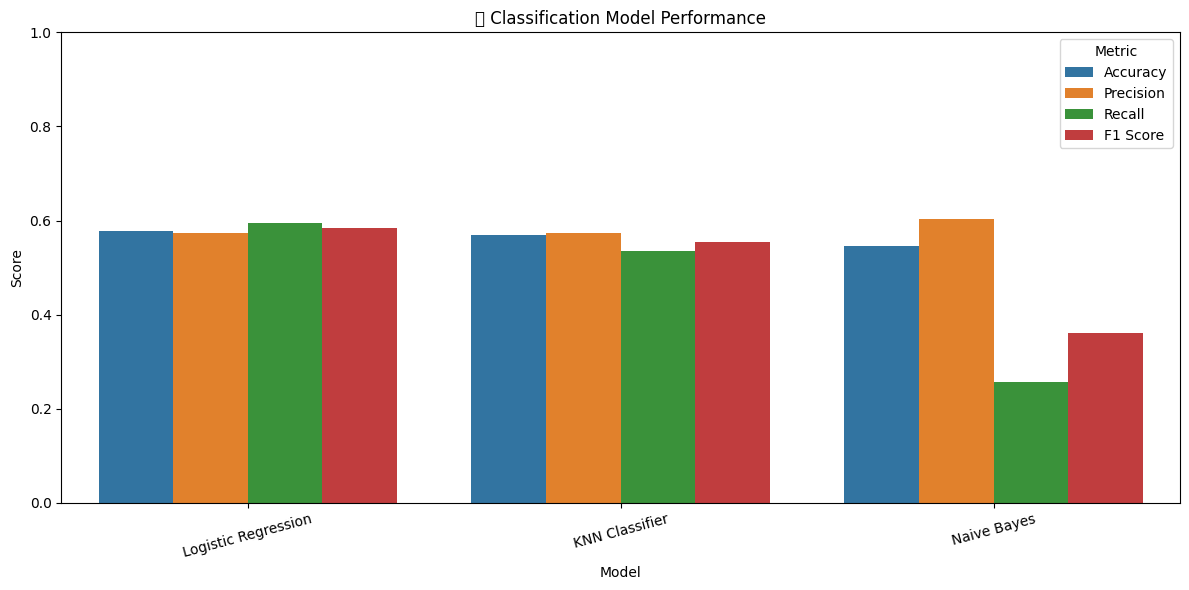

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt classification metrics for grouped bar plot
class_melted = classification_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=class_melted, x='Model', y='Score', hue='Metric')
plt.title('📊 Classification Model Performance')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# 3.  Visualize Regression Metrics

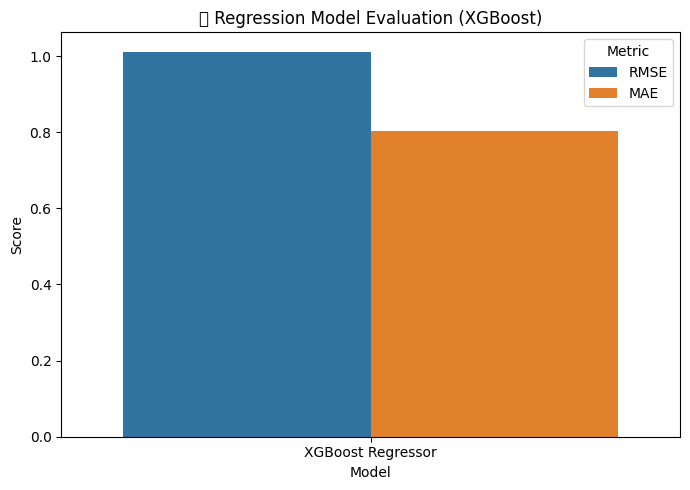

In [ ]:
reg_melted = regression_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(7, 5))
sns.barplot(data=reg_melted, x='Model', y='Score', hue='Metric')
plt.title('📉 Regression Model Evaluation (XGBoost)')
plt.tight_layout()
plt.show()


# Manual Testing Options (for Demo / Streamlit )


# 1. Test Classification Models — Will a user like a movie?

In [ ]:
# Pick a random sample
i = 4800  # any index
X_sample = X_test.iloc[i:i+1]

# Predict with different classifiers
logistic_pred = clf.predict(X_sample)[0]
knn_pred = knn_clf.predict(X_sample)[0]
nb_pred = nb.predict(X_sample)[0]
xgb_bin_pred = (xgb.predict(X_sample) >= 4).astype(int)[0]

print(f"Checking whether the user liked the movie")
print("🎬 True label (liked):", y_test.iloc[i])
print(" Logistic:", logistic_pred, " | KNN:", knn_pred, " | NB:", nb_pred, " | XGB:", xgb_bin_pred)


Checking whether the user liked the movie
🎬 True label (liked): 1
 Logistic: 0  | KNN: 0  | NB: 0  | XGB: 0


In [ ]:
# Pick a random sample
i = 234  # any index
X_sample = X_test.iloc[i:i+1]

# Predict with different classifiers
logistic_pred = clf.predict(X_sample)[0]
knn_pred = knn_clf.predict(X_sample)[0]
nb_pred = nb.predict(X_sample)[0]
xgb_bin_pred = (xgb.predict(X_sample) >= 4).astype(int)[0]
print("Checking whether the user liked the movie")
print("🎬 True label (liked):", y_test.iloc[i])
print(" Logistic:", logistic_pred, " | KNN:", knn_pred, " | NB:", nb_pred, " | XGB:", xgb_bin_pred)


🎬 True label (liked): 0
🤖 Logistic: 1  | KNN: 1  | NB: 0  | XGB: 0


# 2. Top N Recommendations for a User (Collaborative Filtering)

In [ ]:
print("🎬 Recommendations for user 17040 using Collaborative Filtering ")
print(get_top_n_recommendations(predictions, user_id=17040))


🎬 Recommendations for user 17040 using Collaborative Filtering 
                                            title  avg_rating
6010                      Shanghai Knights (2003)    3.038462
19864                        Robot Stories (2003)    3.500000
92856  Fubar II (Fubar: Balls to the Wall) (2010)    3.500000


# 3. Actual vs Predicted Rating (XGBoost)

In [ ]:
i = 5  # sample index
pred_rating = xgb.predict(X_test.iloc[i:i+1])[0]
true_rating = y_test.iloc[i]

print("For that movie here is the rating given by user")
print(f"🎬 Movie: {movielens_dataset['title'].iloc[i]}")
print(f"🎯 XGBoost Prediction: {pred_rating:.2f} | True Rating: {true_rating}")


For that movie here is the rating given by user
🎬 Movie: No Escape (1994)
🎯 XGBoost Prediction: 3.65 | True Rating: 0


# Showing XGBoost predictions for 20 movies:

In [ ]:
print(" Showing XGBoost predictions for 20 movies:")

for i in range(20):
    pred_rating = xgb.predict(X_test.iloc[i:i+1])[0]
    true_rating = y_test.iloc[i]

    print("\nFor that movie, here is the rating given by user:")
    print(f"🎬 Movie: {movielens_dataset['title'].iloc[i]}")
    print(f" XGBoost Prediction: {pred_rating:.2f} | True Rating: {true_rating}")


 Showing XGBoost predictions for 20 movies:

For that movie, here is the rating given by user:
🎬 Movie: Shrek 2 (2004)
 XGBoost Prediction: 3.45 | True Rating: 0

For that movie, here is the rating given by user:
🎬 Movie: Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
 XGBoost Prediction: 3.61 | True Rating: 1

For that movie, here is the rating given by user:
🎬 Movie: Grand Budapest Hotel, The (2014)
 XGBoost Prediction: 3.62 | True Rating: 0

For that movie, here is the rating given by user:
🎬 Movie: Swingers (1996)
 XGBoost Prediction: 3.69 | True Rating: 1

For that movie, here is the rating given by user:
🎬 Movie: Big Lebowski, The (1998)
 XGBoost Prediction: 3.81 | True Rating: 1

For that movie, here is the rating given by user:
🎬 Movie: No Escape (1994)
 XGBoost Prediction: 3.65 | True Rating: 0

For that movie, here is the rating given by user:
🎬 Movie: U.S. Marshals (1998)
 XGBoost Prediction: 3.46 | True Rating: 1

For that movie, here is the rating given by user:
🎬 Movie: Cube Z

# Create the dataset to use for streamlit

In [ ]:
# Step 1: Sample 100k rows
movielens_sample = movielens_dataset.sample(100_000, random_state=42).copy()

# Step 2: Drop duplicates to avoid multiple ratings for same movie
movielens_sample = movielens_sample.drop_duplicates(subset=['movieId'])

# Step 3: Keep only relevant columns
final_cols = ['movieId', 'title', 'genres', 'avg_rating', 'rating_count']
if 'rating_count_scaled' in movielens_sample.columns:
    final_cols.append('rating_count_scaled')
if 'liked' in movielens_sample.columns:
    final_cols.append('liked')

# Step 4: Save to CSV
movielens_sample[final_cols].to_csv("movielens_cleaned.csv", index=False)
print("✅ File saved as movielens_cleaned.csv")


✅ File saved as movielens_cleaned.csv
